# **NOTE:** Use File > Save a copy in Drive to make a copy before doing anything else

# Project 6: Data Exploration and Visualization

### Overview

For this project I decided to use a FIFA World Cup dataset. I thought it would be interesting to look at because soccer is popular worldwide and there is a lot of data going back to 1930. I want to see how scoring has changed over the years and which countries score the most goals.

## Part 1: Dataset Selection and Initial Exploration

### 1. Dataset Selection

**Dataset:** FIFA World Cup Match Results (1930–2022)  
**Source:** [Kaggle – FIFA World Cup Dataset](https://www.kaggle.com/datasets/abecklas/fifa-world-cup)

I found this dataset on Kaggle. It has over 900 rows and each row is one match from a World Cup tournament. The columns include things like the two teams playing, how many goals each team scored, what year it was, and what stage of the tournament it was (like Group Stage or Final). It has both number columns and text columns so I think it works well for this project.

### 2. Import Libraries

In [14]:
# importing the libraries we need
# pandas is for loading and working with the data
# matplotlib and seaborn are for making the charts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Load the Data

In [15]:
# pd.read_csv reads the file and stores it as a dataframe
import kagglehub
import os

# Download the dataset using kagglehub
# The dataset is 'abecklas/fifa-world-cup' as mentioned in the notebook's description
dataset_path = kagglehub.dataset_download("abecklas/fifa-world-cup")

# Construct the full path to the CSV file
# Assuming the CSV file is directly in the downloaded directory
csv_file_path = os.path.join(dataset_path, 'WorldCupMatches.csv')

df = pd.read_csv(csv_file_path)

print('data loaded!')

Using Colab cache for faster access to the 'fifa-world-cup' dataset.
data loaded!


### 4. Data Summary

In [16]:
# info() shows the column names, how many non-null values there are, and the data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  852 non-null    float64
 1   Datetime              852 non-null    object 
 2   Stage                 852 non-null    object 
 3   Stadium               852 non-null    object 
 4   City                  852 non-null    object 
 5   Home Team Name        852 non-null    object 
 6   Home Team Goals       852 non-null    float64
 7   Away Team Goals       852 non-null    float64
 8   Away Team Name        852 non-null    object 
 9   Win conditions        852 non-null    object 
 10  Attendance            850 non-null    float64
 11  Half-time Home Goals  852 non-null    float64
 12  Half-time Away Goals  852 non-null    float64
 13  Referee               852 non-null    object 
 14  Assistant 1           852 non-null    object 
 15  Assistant 2          

In [17]:
# describe() gives us stats like mean, min, max for the number columns
df.describe()

,Year,Home Team Goals,Away Team Goals,Attendance,Half-time Home Goals,Half-time Away Goals,RoundID,MatchID
count,852.000000,852.000000,852.000000,850.000000,852.000000,852.000000,8.520000e+02,8.520000e+02
mean,1985.089202,1.811033,1.022300,45164.800000,0.708920,0.428404,1.066177e+07,6.134687e+07
std,22.448825,1.610255,1.087573,23485.249247,0.937414,0.691252,2.729613e+07,1.110572e+08
min,1930.000000,0.000000,0.000000,2000.000000,0.000000,0.000000,2.010000e+02,2.500000e+01
25%,1970.000000,1.000000,0.000000,30000.000000,0.000000,0.000000,2.620000e+02,1.188750e+03
50%,1990.000000,2.000000,1.000000,41579.500000,0.000000,0.000000,3.370000e+02,2.191000e+03
75%,2002.000000,3.000000,2.000000,61374.500000,1.000000,1.000000,2.497220e+05,4.395006e+07
max,2014.000000,10.000000,7.000000,173850.000000,6.000000,5.000000,9.741060e+07,3.001865e+08


In [18]:
# head() shows the first 5 rows so I can see what the data looks like
df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [19]:
# shape tells me how many rows and columns there are
print(df.shape)

(4572, 20)


In [20]:
# columns shows me all the column names
print(df.columns)

Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials'],
      dtype='object')


### 5. Inquiry Question

**How has the average number of goals per match changed over the years, and which countries have scored the most total goals in World Cup history?**

## Part 2: Data Visualization and Analysis

### 1. Data Cleaning

In [21]:
# checking if there are any missing values
print(df.isnull().sum())

Year                    3720
Datetime                3720
Stage                   3720
Stadium                 3720
City                    3720
Home Team Name          3720
Home Team Goals         3720
Away Team Goals         3720
Away Team Name          3720
Win conditions          3720
Attendance              3722
Half-time Home Goals    3720
Half-time Away Goals    3720
Referee                 3720
Assistant 1             3720
Assistant 2             3720
RoundID                 3720
MatchID                 3720
Home Team Initials      3720
Away Team Initials      3720
dtype: int64


In [22]:
# dropping rows where the goal columns are empty since we need those
df.dropna(subset=['Home Team Goals', 'Away Team Goals'], inplace=True)

# also removing duplicate rows just in case
df.drop_duplicates(inplace=True)

# making the goal columns integers so I can do math with them
df['Home Team Goals'] = df['Home Team Goals'].astype(int)
df['Away Team Goals'] = df['Away Team Goals'].astype(int)

# adding a new column for total goals in each match
df['Total Goals'] = df['Home Team Goals'] + df['Away Team Goals']

# making sure Year is an integer too
df['Year'] = df['Year'].astype(int)

print('done cleaning!')
print('rows left:', len(df))

done cleaning!
rows left: 836


### 2 & 3. Visualizations

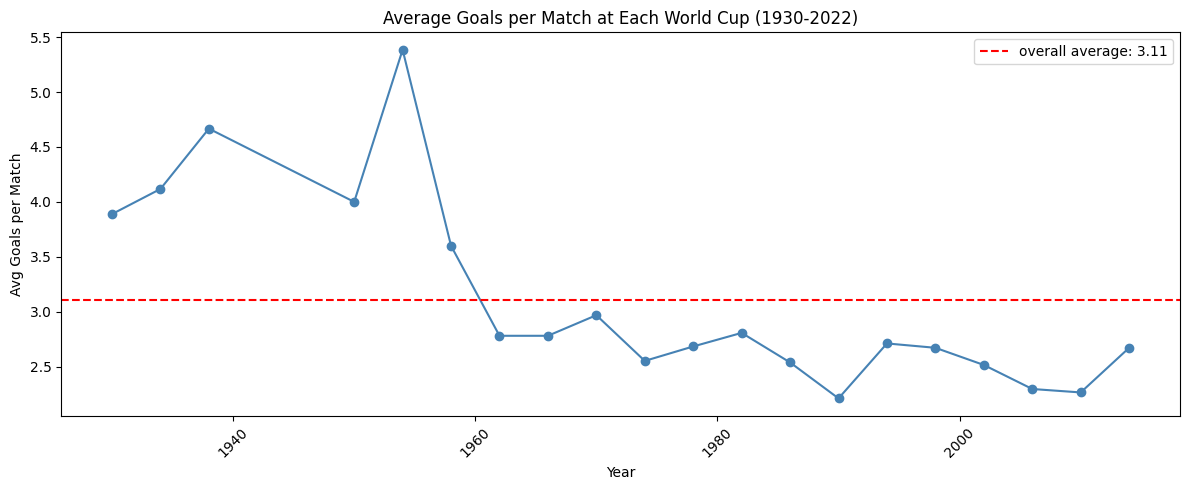

In [23]:
# Visualization 1 - Line chart showing average goals per match each year

avg_goals = df.groupby('Year')['Total Goals'].mean()

plt.figure(figsize=(12, 5))
plt.plot(avg_goals.index, avg_goals.values, marker='o', color='steelblue')

# adding a horizontal line for the overall average so its easier to compare
overall = avg_goals.mean()
plt.axhline(overall, color='red', linestyle='--', label=f'overall average: {overall:.2f}')

plt.title('Average Goals per Match at Each World Cup (1930-2022)')
plt.xlabel('Year')
plt.ylabel('Avg Goals per Match')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

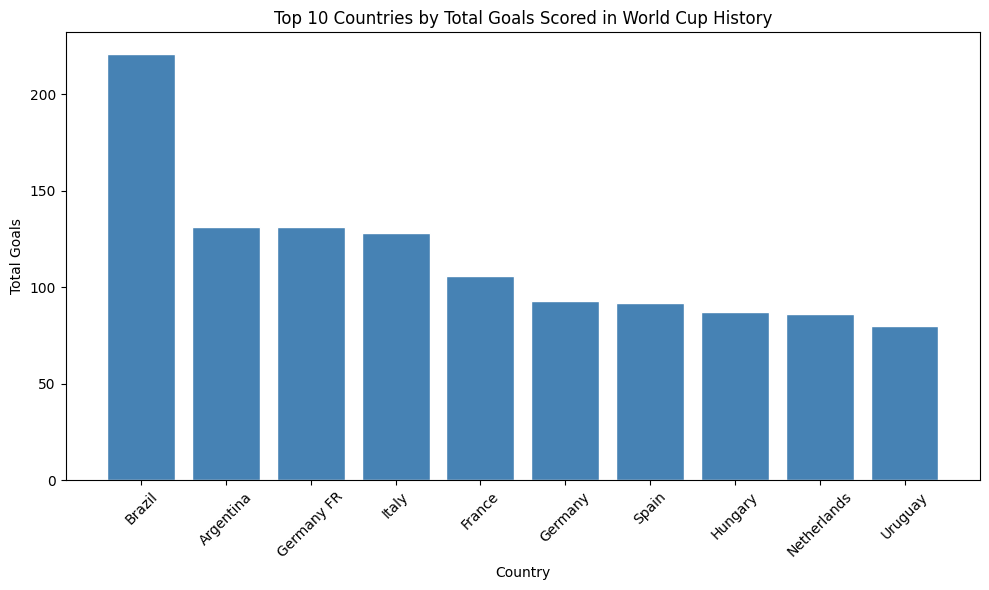

In [24]:
# Visualization 2 - Bar chart for top 10 countries by total goals scored
# I had to add up goals from both the home and away columns

# getting goals scored as home team
home = df.groupby('Home Team Name')['Home Team Goals'].sum()

# getting goals scored as away team
away = df.groupby('Away Team Name')['Away Team Goals'].sum()

# combining them together
all_goals = home.add(away, fill_value=0).astype(int)

# sorting and taking the top 10
top10 = all_goals.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values, color='steelblue', edgecolor='white')

plt.title('Top 10 Countries by Total Goals Scored in World Cup History')
plt.xlabel('Country')
plt.ylabel('Total Goals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4115/567105751.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered, x='Stage', y='Total Goals',


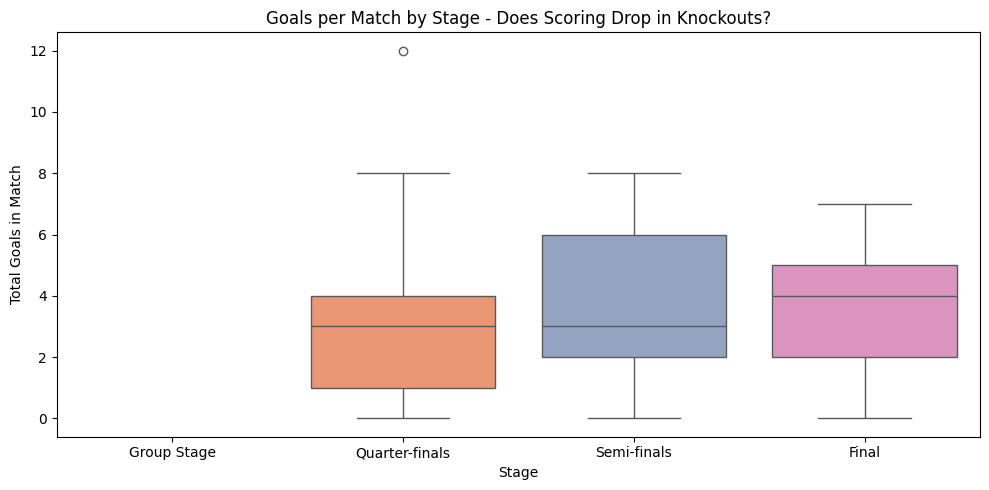

In [25]:
# Visualization 3 (bonus) - Box plot comparing goals in group stage vs knockout rounds
# I was curious if finals and semis have less goals than group stage games because I felt like teams play better/safer soccer

# filtering to just the stages I want to look at
stages = ['Group Stage', 'Quarter-finals', 'Semi-finals', 'Final']
filtered = df[df['Stage'].isin(stages)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=filtered, x='Stage', y='Total Goals',
            order=stages, palette='Set2')

plt.title('Goals per Match by Stage - Does Scoring Drop in Knockouts?')
plt.xlabel('Stage')
plt.ylabel('Total Goals in Match')
plt.tight_layout()
plt.show()

### 4. Analysis

Looking at my first chart, you can see that World Cup games in the 1950s had way more goals on average than games today. The 1954 World Cup in Switzerland had the most goals by far, with an average of over 5 goals per game. After that the average slowly came down and has stayed pretty steady around 2.5 goals per game since the 1980s. I think this is because teams got better at defending over time and coaching became more tactical. It was kind of surprising to me how big the difference is between early World Cups and modern ones.

For the second chart, Brazil and Germany are clearly the top two countries for total goals scored which makes sense since they are also the most successful teams in World Cup history. The third chart about stages was interesting too. Group stage games actually have a slightly higher median than finals and semi-finals, which shows that teams do play more carefully when they cant afford to lose. One limitation of my analysis is that I did not separate out extra time goals so some matches might have more goals just because they went longer. In the future it would be cool to look at whether home country advantage (when the World Cup is hosted nearby) affects scoring.